# **Homework 3**  - Deep Learning Winter 2024

#  Text Generation & Latent Space Visualization

Student 1: Rajaa Haj 322512690

Student 2: Aseel Shaheen 212393532



In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# **Part 1 : Song Lyrics Generation**



In [9]:
import pandas as pd
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader,TensorDataset
from google.colab import files
import os



## *Study the data:*

### Load the CSV:

we will start by loading the Songs CSV file into Dataframe using pandas and showcase a couple of rows from it.





In [3]:
# Load the data from the csv file
data_path='/content/drive/MyDrive/Songs.csv'
data=pd.read_csv(data_path, encoding='utf-8')
data.head(n=10) # Display the first 10 rows of the data

,Artist,Title,Lyrics
0,Taylor Swift,cardigan,"Vintage tee, brand new phone\nHigh heels on co..."
1,Taylor Swift,exile,"I can see you standing, honey\nWith his arms a..."
2,Taylor Swift,Lover,We could leave the Christmas lights up 'til Ja...
3,Taylor Swift,the 1,"I'm doing good, I'm on some new shit\nBeen say..."
4,Taylor Swift,Look What You Made Me Do,I don't like your little games\nDon't like you...
5,Taylor Swift,betty,"Betty, I won't make assumptions\nAbout why you..."
6,Taylor Swift,august,"Salt air, and the rust on your door\nI never n..."
7,Taylor Swift,End Game,I wanna be your end game\nI wanna be your firs...
8,Taylor Swift,You Need To Calm Down,You are somebody that I don't know\nBut you're...
9,Taylor Swift,ME!,I promise that you'll never find another like ...


1) we will print all of the artist's names and show how many songs are associated with each artists

In [4]:
# count the number of songs assoicated for each artist
artist_song_counts=data['Artist'].value_counts()

for artist, count in artist_song_counts.items():

  print(f"{artist}: {count} songs")

Taylor Swift: 50 songs
Billie Eilish: 50 songs
David Bowie: 50 songs
Billy Joel: 50 songs
Eric Clapton: 50 songs
Leonard Cohen: 50 songs
Bruce Springsteen: 40 songs
The Beatles: 35 songs
Vance Joy: 30 songs
Bryan Adams: 30 songs
Lana Del Rey: 30 songs
Nat King Cole: 30 songs
​twenty one pilots: 30 songs
Elton John: 30 songs
Ray LaMontagne: 30 songs
John Denver: 30 songs
Frank Sinatra: 30 songs
George Michael: 30 songs
Queen: 30 songs
Ed Sheeran: 20 songs
Bob Dylan: 20 songs


2)  We will print the size of the dataset and how many songs are there.

In [15]:
data_size=data.shape

print(f"The size of the dataset is {data_size} \n")
print(f"The number of rows in the dataset is {data_size[0]} \n")
print(f"The number of columns in the dataset is {data_size[1]} \n")

songs_num= len(data)

print(f"The number of songs in the dataset is {songs_num}")



The size of the dataset is (745, 3) 

The number of rows in the dataset is 745 

The number of columns in the dataset is 3 

The number of songs in the dataset is 745


3) We will print the average number of characters and words of a song for all songs lyrics in the dataset ( the average length of a song).



In [16]:
total_char=0
total_words=0

for lyrics in data['Lyrics']:
  total_char+=len(lyrics)
  total_words+=len(lyrics.split())

avg_char=total_char/songs_num
avg_word=total_words/songs_num


print(f"The average number of characters per song : {avg_char} \n")
print(f"The average number of words per song : {avg_word} \n")

The average number of characters per song : 1403.3476510067114 

The average number of words per song : 276.26040268456376 



4)  We will print the top 3 most used words in the congs and visualize the data using word cloud image .

The Top 3 most used words is:

the : 8135 times 

i : 6722 times 

you : 6632 times 



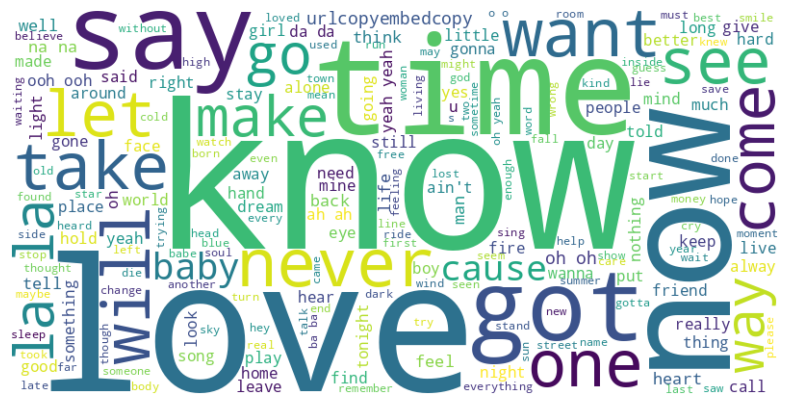

In [ ]:

all_lyrics=' '.join(data['Lyrics'].tolist()).lower()
all_words=all_lyrics.split()
words_counts=Counter(all_words)

# get the top 3 used words
top_3_words=words_counts.most_common(3)

# print the top 3 used words
print("The Top 3 most used words is:\n")
for word, count in top_3_words:

  print(f"{word} : {count} times \n")


# Display the word cloud

word_cloud=WordCloud(width=800, height =400 , background_color='white').generate(all_lyrics)

plt.figure(figsize=(10,5))
plt.imshow(word_cloud , interpolation='bilinear')
plt.axis('off')
plt.show()






# *Preprocessing:*



*   we will start by creating a corpus from the given lyrics by extracting the Lyrics column , drop any missing values (using dropna()) and build our corpus from all lyrics .

*   we clean the Corpus from unnecessary symbols and keep only : English letters , numbers , punctuation marks and whitespace .


*   In order to encode the data before training the model :<br>
1) we start by Tokenizing the Text by splitting the cleaned corpus into individual words , then creating a vocabulary dictionary where each word is mapped to unique index . <br>
2) we convert the words to sequences by replacing each word from the vocab with its corresponding numerical index and create a list of numbers to representing all the corpus .








In [5]:
# create the corpus
corpus="\n".join(data["Lyrics"].dropna().astype(str))


# clean the corpus
# keeping only English letters ,digits, punctutaion and whitespace and remove everything else
cleaned_corpus=re.sub(r"[^a-zA-Z0-9.,!?'\s]","" ,corpus)
cleaned_corpus=cleaned_corpus.lower()


#Encode the data
#step 1: Tokenize the text
words= cleaned_corpus.split()
word_counts=Counter(words)
vocab=sorted(word_counts.keys())
word_to_index={ word:i for i, word in enumerate(vocab)}
index_to_word={i: word for word,i in word_to_index.items()}

encoded_corpus=[word_to_index[word] for word in words]


sequence_length=50
step=1
input_sequences=[]
target_sequences=[]

for i in range(0,len(encoded_corpus)-sequence_length,step):
  input_sequences.append(encoded_corpus[i:i+sequence_length])
  target_sequences.append(encoded_corpus[i+sequence_length])







# *Model Definition and training :*

## *Define The Model:*

We will use LSTM model to handle sequential data .
We choose the loss function :
The Optimizer :


In [6]:
class LSTMModel(nn.Module):


  def __init__(self, vocab_size, embedding_dim=100, hidden_dim=128,num_layers=2):

    super(LSTMModel, self).__init__()
    self.embedding=nn.Embedding(vocab_size, embedding_dim)
    self.lstm=nn.LSTM(embedding_dim,hidden_dim,num_layers,batch_first=True)
    self.fc=nn.Linear(hidden_dim,vocab_size)


  def forward(self,x):

    embedded=self.embedding(x)
    lstm_out,_=self.lstm(embedded)
    output=self.fc(lstm_out[:,-1,:])

    return output




## Train the model :

In [10]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

# convert to PyTorch tensors
X=torch.tensor(input_sequences, dtype=torch.long)
y=torch.tensor(target_sequences,dtype=torch.long)


batch_size=64
dataset=TensorDataset(X,y)
dataloader=DataLoader(dataset,batch_size=batch_size , shuffle=True )



vocab_size=len(vocab)
model=LSTMModel(vocab_size).to(device)
criterion= nn.CrossEntropyLoss()
learning_rate=0.001
optimizer=optim.Adam(model.parameters(), lr=learning_rate)




model_path='/content/drive/MyDrive/lstm_model.pth'

if os.path.exists(model_path):

      print("loading model....")
      model.load_state_dict(torch.load(model_path))
      model.to(device)

else:

      print("training the model ......")

      num_epochs=100
      losses=[]
      for epoch in range(num_epochs):
          total_loss=0
          for batch_X,batch_y in dataloader:
            batch_X,batch_y=batch_X.to(device),batch_y.to(device)
            optimizer.zero_grad()
            outputs=model(batch_X)
            loss=criterion(outputs,batch_y)
            loss.backward()
            optimizer.step()
            total_loss+=loss.item()
          avg_loss=total_loss/len(dataloader)

          losses.append(avg_loss)
          print(f"Epoch[{ epoch+1}/{num_epochs}],Loss: {avg_loss:.4f}")




      torch.save(model.state_dict(),model_path)
      files.download(model_path)











training the model ......
Epoch[1/100],Loss: 6.3667
Epoch[2/100],Loss: 5.6175
Epoch[3/100],Loss: 5.1283
Epoch[4/100],Loss: 4.6926
Epoch[5/100],Loss: 4.3084
Epoch[6/100],Loss: 3.9730
Epoch[7/100],Loss: 3.6798
Epoch[8/100],Loss: 3.4224
Epoch[9/100],Loss: 3.1948
Epoch[10/100],Loss: 2.9935
Epoch[11/100],Loss: 2.8161
Epoch[12/100],Loss: 2.6563
Epoch[13/100],Loss: 2.5150
Epoch[14/100],Loss: 2.3857
Epoch[15/100],Loss: 2.2679
Epoch[16/100],Loss: 2.1621
Epoch[17/100],Loss: 2.0620
Epoch[18/100],Loss: 1.9702
Epoch[19/100],Loss: 1.8858
Epoch[20/100],Loss: 1.8092
Epoch[21/100],Loss: 1.7376
Epoch[22/100],Loss: 1.6702
Epoch[23/100],Loss: 1.6090
Epoch[24/100],Loss: 1.5507
Epoch[25/100],Loss: 1.4960
Epoch[26/100],Loss: 1.4469
Epoch[27/100],Loss: 1.3975
Epoch[28/100],Loss: 1.3542
Epoch[29/100],Loss: 1.3126
Epoch[30/100],Loss: 1.2830
Epoch[31/100],Loss: 1.2223
Epoch[32/100],Loss: 1.2030
Epoch[33/100],Loss: 1.1718
Epoch[34/100],Loss: 1.1401
Epoch[35/100],Loss: 1.1098
Epoch[36/100],Loss: 1.0838
Epoch[37/10

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

plot

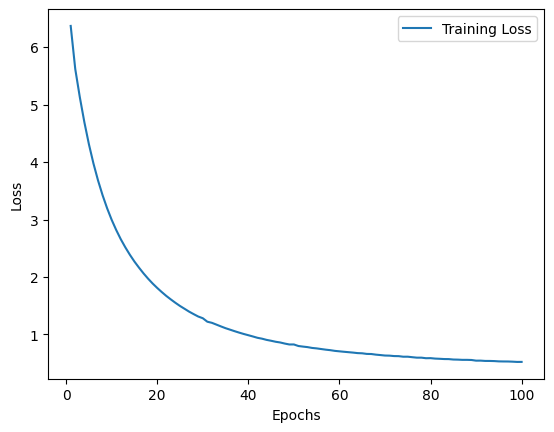

In [11]:
plt.plot(range(1,num_epochs+1) , losses ,label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

## **Evaluation:**

In [12]:
def load_trained_model(model_path, vocab_size):

  model=LSTMModel(vocab_size)
  model.load_state_dict(torch.load(model_path))
  model.to(device)
  model.eval()
  return model


In [53]:
# Function to generated lyrics with different strategies

def sample_with_temperature(predictions , temperature=1.2):

  predictions=predictions/temperature
  probabilities=torch.nn.functional.softmax(predictions,dim=0)
  return torch.multinomial(probabilities,1).item()



# def sample_with_top_p(prediction, top_p=0.8):

#    sorted_indx=torch.argsort(prediction,descending=True)
#    sorted_prob=torch.nn.functional.softmax(prediction[sorted_indx],dim=0)
#    cum_prop=torch.cumsum(sorted_prob,dim=0)
#    filtered_indx=sorted_indx[cum_prop<=top_p]

#    if len(filtered_indx)==0:
#     filtered_indx=filtered_indx[:1]


#    selected_indx=filtered_indx[torch.multinomial(sorted_prob[:len(filtered_indx)],1)].item()

#    return selected_indx




In [54]:
def LyricsGenerator(starting_string , char_count , strategy="argmax", temp=1.0 , top_k=5 , top_p=0.9):

  #model=load_trained_model(model_path,vocab_size)
  model.eval()
  words=starting_string.lower().split()
  generated_lyrics=words[:]


  ## convert words to indx
  input_seq=[word_to_index[word] for word in words if word in word_to_index]
  input_seq=torch.tensor(input_seq,dtype=torch.long).unsqueeze(0).to(device)


  while len(" ".join(generated_lyrics)) < char_count:
    with torch.no_grad():

        output=model(input_seq)
        #predicted_index=torch.argmax(output,dim=1).item()
        #predicted_word=index_to_word.get(predicted_index,"")
        #generated_lyrics.append(predicted_word)
        predictions=output.squeeze(0)

        if strategy=="temperature":

           predicted_index=sample_with_temperature(predictions,temp)

        elif strategy=="top_k":

            top_values,top_indices=torch.topk(predictions,k=top_k)
            predicted_index=top_indices[torch.multinomial(torch.nn.functional.softmax(top_values,dim=-1),1)].item()

        # elif strategy=="top_p":

        #     predicted_index=sample_with_top_p(predictions,top_p)


        # else:

        #     predicted_index=torch.argmax(predictions,dim=1).item()

        predicted_word=index_to_word.get(predicted_index,"")
        generated_lyrics.append(predicted_word)
        #update input sequence
        input_seq=torch.cat([input_seq[:,1:], torch.tensor([[predicted_index]],dtype=torch.long).to(device)],dim=1)


  return " ".join(generated_lyrics)




print("Generated Song 1:")
print("strategy : temp")
generated_song1=LyricsGenerator("it's not a silly little moment...",avg_char,strategy="temperature")
print(generated_song1)
print("strategy : top_k")
generated_song2=LyricsGenerator("it's not a silly little moment...",avg_char,strategy="top_k")
print(generated_song2)
# print("strategy : top_p")
# generated_song3=LyricsGenerator("it's not a silly little moment...",avg_char,strategy="top_p")
# print(generated_song3)

# print("\nGenerated Song 2:")
# generated_song2=LyricsGenerator("")


# print("Generated Song 3:")
# generated_song3=LyricsGenerator(" ",avg_char)
# print(generated_song3)



Generated Song 1:
strategy : temp
it's not a silly little moment... though we always babe, you, did one younger to others your downeaster far with you? we carry forever ah, you can love, ah you need my fun, pride you that's very bleed and it felt new rich, unknown not it if hold it could let it let everythings only greed sign naked plant had the superman was you've known me to me rub you keep me away, ya save me, my sorry and let it may cry, gettin' yeah and what show but i've been playin' ladies and dark luck the people shes seven huddled lala, bleedin' ronnie, too dont the dead, and my bennie, own love may if you should love left to speak else to light along well so let it hang out of the start wrap so blue it hide you ridin' me to everybody arise41embedshare school, up for all party im away lit care i says now i would taking i sun fever is it naa time bind my man, run boy wake to her rifle where the coming sleep, sat urlcopyembedcopy you've bet youembedshare dirty faith may shine, y